The following notebook structure is mostly LLM generated to get a quick compatibility with the built multi-model config system.

In [264]:
from __future__ import annotations

from pathlib import Path
import pickle
import yaml
import numpy as np
import pandas as pd
import torch
import soundfile as sf
from tqdm import tqdm

from dcase.src.cnn_experiment import CNNExperiment
from dcase.src.models import EnsembleCNNModel, SklearnAudioEnsembleClassifier, CNNTCNModel, DualChannelCNNModel
from models import BaselineModel, LinSeqModel, CNNModel, SklearnAudioClassifier, DualChannelCNNModel
from baseline_experiment import BaselineExperiment
from dataset import AcousticScenesDataset

In [265]:
MODEL_REGISTRY = {
    "BaselineModel": BaselineModel,
    "LinSeqModel": LinSeqModel,
    "CNNModel": CNNModel,
    "EnsembleCNNModel": EnsembleCNNModel,
    "SklearnAudioClassifier": SklearnAudioClassifier,
    "SklearnAudioEnsembleClassifier": SklearnAudioEnsembleClassifier,
    "CNNTCNModel": CNNTCNModel,
    "DualChannelCNNModel": DualChannelCNNModel,
}

EXPERIMENT_REGISTRY = {
    "BaselineModel": BaselineExperiment,
    "LinSeqModel": BaselineExperiment,
    "CNNModel": CNNExperiment,
    "EnsembleCNNModel": CNNExperiment,
    "CNNTCNModel": CNNExperiment,
    "DualChannelCNNModel": CNNExperiment,
}

SKLEARN_MODELS = {"SklearnAudioClassifier", "SklearnAudioEnsembleClassifier"}
PYTORCH_MODELS = set(MODEL_REGISTRY) - SKLEARN_MODELS

In [266]:
def read_audio_as_numpy(audio_path: str | Path) -> tuple[np.ndarray, int]:
    """Read audio file and return (np.ndarray [channels, time], sample_rate)."""
    audio_np, sr = sf.read(str(audio_path), dtype=np.float32, always_2d=True)
    # Transpose to shape [channels, time]
    return audio_np.T, sr

def ensure_2d_time_channels(audio_np: np.ndarray) -> np.ndarray:
    """Ensure audio is [channels, time]."""
    if audio_np.ndim == 1:
        return audio_np[None, :]
    if audio_np.ndim == 2:
        return audio_np
    raise ValueError(f"Unexpected audio ndim={audio_np.ndim}, shape={audio_np.shape}")

def to_mono_if_requested(audio_tc: np.ndarray, mono: bool) -> np.ndarray:
    """Convert [channels, time] to mono if requested."""
    if not mono:
        return audio_tc
    return audio_tc.mean(axis=0, keepdims=True).astype(np.float32)

def to_torch_tensor(audio_tc: np.ndarray) -> torch.Tensor:
    """Convert [channels, time] numpy to torch tensor."""
    return torch.tensor(audio_tc, dtype=torch.float32)

def load_yaml(path: str | Path) -> dict:
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

In [267]:
def infer_label_from_logits(logits: torch.Tensor) -> int:
    if logits.ndim == 1:
        return int(logits.argmax().item())

    if logits.ndim == 2:
        # assume (batch, classes)
        return int(logits.argmax(dim=-1)[0].item())

    raise ValueError(f"Unexpected logits shape {logits.shape}")


def load_model_and_runner(config: dict, ckpt_path: str | Path):
    model_name = config["model"]
    ckpt_path = Path(ckpt_path)
    info = {"model_name": model_name, "ckpt_path": str(ckpt_path)}

    # --- SKLEARN MODELS ---
    if model_name in SKLEARN_MODELS:
        with ckpt_path.open("rb") as f:
            ckpt = pickle.load(f)
        if model_name == "SklearnAudioEnsembleClassifier":
            model = SklearnAudioEnsembleClassifier(
                base_classifiers=config["ensemble"]["base_classifiers"],
                final_estimator=config["ensemble"]["final_estimator"],
                ensemble_type=config["ensemble"]["type"],
            )
            if "model" in ckpt and ckpt["model"] is not None:
                loaded = ckpt["model"]
                if isinstance(loaded, SklearnAudioEnsembleClassifier):
                    model = loaded
                elif hasattr(loaded, "predict") and hasattr(loaded, "fit"):
                    model.ensemble = loaded
                else:
                    raise TypeError(f"Unsupported ckpt['model'] type: {type(loaded)}.")
            if "ensemble" in ckpt and ckpt["ensemble"] is not None:
                model.ensemble = ckpt["ensemble"]
            if "pipeline" in ckpt and ckpt["pipeline"] is not None:
                model.pipeline = ckpt["pipeline"]

            def runner(audio_tc: torch.Tensor) -> int:
                if audio_tc.shape[0] != 1:
                    audio_tc = audio_tc.mean(dim=0, keepdim=True)
                features = model.extract_features(audio_tc.cpu())
                if hasattr(model, "ensemble") and model.ensemble is not None:
                    return int(model.ensemble.predict(features)[0])
                if hasattr(model, "pipeline"):
                    return int(model.pipeline.predict(features)[0])
                raise RuntimeError("SklearnAudioEnsembleClassifier has neither 'ensemble' nor 'pipeline' loaded.")

            info["runner_type"] = "sklearn_ensemble"
            return runner, info

        # Standard sklearn model
        clf_type = str(config["network"]["type"])
        params = config["network"].get("params", {})
        model = SklearnAudioClassifier(
            classifier_type=clf_type,
            sample_rate=int(config["data"]["sample_rate"]),
            n_fft=int(config["network"].get("n_fft", 2048)),
            hop_length=int(config["network"].get("hop_length", 882)),
            n_mels=int(config["network"].get("n_mels", 40)),
            n_estimators=int(params.get("n_estimators", 500)),
            max_depth=int(params.get("max_depth", 20)),
            n_components=int(params.get("n_components", 100)),
            svm_C=float(params.get("svm_C", 10.0)),
            svm_kernel=str(params.get("svm_kernel", "rbf")),
            win_length=int(config["network"].get("win_length", 2048)),
        )
        if "pipeline" in ckpt and ckpt["pipeline"] is not None:
            model.pipeline = ckpt["pipeline"]
        elif "model" in ckpt:
            loaded = ckpt["model"]
            if isinstance(loaded, SklearnAudioClassifier):
                model = loaded
            elif hasattr(loaded, "predict") and hasattr(loaded, "fit"):
                model.pipeline = loaded
            else:
                raise TypeError(f"Unsupported ckpt['model'] type: {type(loaded)}.")
        else:
            raise KeyError("Checkpoint missing both 'pipeline' and 'model'.")

        def runner(audio_tc: torch.Tensor) -> int:
            if audio_tc.shape[0] != 1:
                audio_tc = audio_tc.mean(dim=0, keepdim=True)
            features = model.extract_features(audio_tc.cpu())
            return int(model.pipeline.predict(features)[0])

        info["runner_type"] = "sklearn"
        return runner, info

    # --- PYTORCH MODELS ---
    if model_name in PYTORCH_MODELS:
        ExpClass = EXPERIMENT_REGISTRY[model_name]
        ModelClass = MODEL_REGISTRY[model_name]

        # Get input_channels from config for multi-stream models
        input_channels = config["data"].get("input_channels", None)

        # ============================================================
        # FIX 1: Create model ONCE with correct parameters per model type
        # ============================================================
        if model_name == 'EnsembleCNNModel':
            model = ModelClass(
                cnn_config=config['network']['cnn_config'],
                dccnn_config=config['network']['dccnn_config'],
                sample_rate=config['data']['sample_rate'],
                shared_mel=config['data']['shared_mel'],
                classifier_hidden=config['network']['classifier_hidden'],
                dropout=config['network']['dropout'],
                pretrained_checkpoints=config['network'].get('pretrained_checkpoints'),
                freeze_submodels=config['network'].get('freeze_submodels', False),
            )
        else:
            # For all other PyTorch models (CNNModel, DualChannelCNNModel, etc.)
            network_config = dict(config['network'])
            network_config['sample_rate'] = config['data']['sample_rate']
            network_config['n_label'] = config['experiment']['n_label']
            if 'augmentation' in config:
                network_config.update(config['augmentation'])
            model = ModelClass(**network_config)

        # ============================================================
        # FIX 2: REMOVED the duplicate model creation that was here:
        #        model = ModelClass(**model_kwargs)  <- THIS WAS THE BUG
        # ============================================================

        # Load checkpoint
        exp = ExpClass.load_from_checkpoint(
            str(ckpt_path), model=model, **config["experiment"]
        )
        exp.eval()
        device = get_device()
        exp.to(device)

        # Preprocessor only for multi-stream models
        preprocessor = None
        if model_name in {"DualChannelCNNModel", "EnsembleCNNModel"}:
            preprocessor = getattr(exp.model, "preprocessor", None)
            if preprocessor is None:
                from preprocessing import MultiStreamPreprocessor
                preprocessor = MultiStreamPreprocessor(
                    sample_rate=config["data"]["sample_rate"],
                    cache_dir=config["data"].get("stream_cache_dir", None)
                )

        # Validate input_channels for multi-channel models
        if model_name == "DualChannelCNNModel":
            if input_channels is None or len(input_channels) != 2:
                raise ValueError("DualChannelCNNModel requires exactly 2 input_channels.")

        if model_name == "EnsembleCNNModel":
            if input_channels is None or len(input_channels) != 6:
                raise ValueError("EnsembleCNNModel requires exactly 6 input_channels.")

        # ============================================================
        # FIX 3: Correct runner implementation for each model type
        # ============================================================
        def runner(audio_tc: torch.Tensor) -> int:
            with torch.inference_mode():
                audio_tc = audio_tc.to(device)

                if model_name == "DualChannelCNNModel":
                    # Process stereo audio into streams
                    streams = preprocessor.process(audio_tc)
                    # Extract the two required channels and add batch dimension
                    audio_ch1 = streams[input_channels[0]].unsqueeze(0).to(device)  # (1, 1, TIME)
                    audio_ch2 = streams[input_channels[1]].unsqueeze(0).to(device)  # (1, 1, TIME)
                    output = exp(audio_ch1, audio_ch2)

                elif model_name == "EnsembleCNNModel":
                    # Process stereo audio into all 6 streams
                    streams = preprocessor.process(audio_tc)
                    # FIX: Correctly assign all 6 channels with proper variable names
                    audio_ch1 = streams[input_channels[0]].unsqueeze(0).to(device)  # left
                    audio_ch2 = streams[input_channels[1]].unsqueeze(0).to(device)  # right
                    audio_ch3 = streams[input_channels[2]].unsqueeze(0).to(device)  # mid
                    audio_ch4 = streams[input_channels[3]].unsqueeze(0).to(device)  # side
                    audio_ch5 = streams[input_channels[4]].unsqueeze(0).to(device)  # harmonic
                    audio_ch6 = streams[input_channels[5]].unsqueeze(0).to(device)  # percussive
                    # FIX: Call forward with 6 positional arguments (not dict)
                    output = exp(audio_ch1, audio_ch2, audio_ch3, audio_ch4, audio_ch5, audio_ch6)

                else:
                    # Mono models (CNNModel, BaselineModel, etc.)
                    if audio_tc.shape[0] != 1:
                        audio_tc = audio_tc.mean(dim=0, keepdim=True)
                    # FIX: Add batch dimension for mono models too
                    audio_tc = audio_tc.unsqueeze(0)  # (1, 1, TIME)
                    output = exp(audio_tc)

                logits = output["logits"] if isinstance(output, dict) else output
            pred = torch.argmax(logits, dim=-1)
            return int(pred[0].item())

        info["runner_type"] = "pytorch"
        info["device"] = str(device)
        return runner, info

    raise ValueError(f"Unknown model type: {model_name}")


In [268]:
import torchaudio

file_path = "../../data/dcase/test/audio/1243.wav"
waveform, sample_rate = torchaudio.load(file_path)
print(f"Audio shape: {waveform.shape}, Sample rate: {sample_rate}")  # Check the shape of the loaded audio

Audio shape: torch.Size([2, 441001]), Sample rate: 44100


In [272]:
# --- User settings ---
CONFIG_PATH = Path("config/dccnn_ms.yaml.yaml")
CKPT_PATH = Path("./../../data/ckpts/cnntcnmodel/epoch=180-val_acc=0.85.ckpt")
TEST_PATH = Path("./../../data/dcase/test/")
GROUPNAME = "fibonacci"

# --- Load config and model ---
config = load_yaml(CONFIG_PATH)
runner, info = load_model_and_runner(config, CKPT_PATH)
print("Loaded:", info)

seed for CNNTCNModel: 1957390947


RuntimeError: Error(s) in loading state_dict for CNNExperiment:
	Missing key(s) in state_dict: "model.cnn_blocks.0.0.running_mean", "model.cnn_blocks.0.0.running_var", "model.cnn_blocks.0.2.weight", "model.cnn_blocks.0.2.bias", "model.cnn_blocks.0.3.running_mean", "model.cnn_blocks.0.3.running_var", "model.cnn_blocks.0.5.weight", "model.cnn_blocks.0.5.bias", "model.cnn_blocks.1.0.running_mean", "model.cnn_blocks.1.0.running_var", "model.cnn_blocks.1.2.weight", "model.cnn_blocks.1.2.bias", "model.cnn_blocks.1.3.running_mean", "model.cnn_blocks.1.3.running_var", "model.cnn_blocks.1.5.weight", "model.cnn_blocks.1.5.bias". 
	Unexpected key(s) in state_dict: "model.cnn_blocks.0.1.weight", "model.cnn_blocks.0.1.bias", "model.cnn_blocks.0.1.running_mean", "model.cnn_blocks.0.1.running_var", "model.cnn_blocks.0.1.num_batches_tracked", "model.cnn_blocks.0.4.weight", "model.cnn_blocks.0.4.bias", "model.cnn_blocks.0.4.running_mean", "model.cnn_blocks.0.4.running_var", "model.cnn_blocks.0.4.num_ba

In [270]:
# --- Prepare test file list ---
meta_path = TEST_PATH / "meta_blind.txt"
meta_df = pd.read_csv(meta_path, delimiter="\t", header=None, names=["audio_path"])
n_samples = len(meta_df)
class_labels = np.empty(n_samples, dtype=int)

# --- Inference loop: dynamic input handling ---
for i in tqdm(range(n_samples), desc="Blind test inference"):
    rel = meta_df.iloc[i]["audio_path"]
    audio_path = TEST_PATH / rel
    try:
        # Load audio as [channels, time]
        audio_np, sr = read_audio_as_numpy(audio_path)
        audio_tc = ensure_2d_time_channels(audio_np)
        audio_tensor = to_torch_tensor(audio_tc)

        # Dynamically adapt input for the loaded model
        if info.get("runner_type") == "pytorch":
            model_name = config["model"]
            est_label = runner(audio_tensor)
        else:
            # Handle sklearn models
            est_label = runner(audio_tensor)
    except Exception as e:
        print(f"Error on file {audio_path}: {e}")
        est_label = -1  # or any invalid label
    class_labels[i] = est_label


Blind test inference: 100%|██████████| 1080/1080 [00:05<00:00, 209.68it/s]


In [271]:
out_df = meta_df.copy()
out_df["class_labels"] = class_labels
out_path = TEST_PATH / f"{GROUPNAME}_{config['model']}_test.csv"
out_df.to_csv(out_path, sep="\t", header=None, index=False)
print("Wrote:", out_path)

Wrote: ..\..\data\dcase\test\fibonacci_CNNTCNModel_test.csv


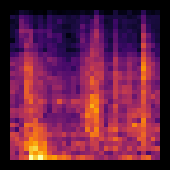

In [32]:
import soundfile as sf
import torch
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F

file_path = "../../data/dcase/test1/audio/318.wav"

# Load audio
waveform, sample_rate = sf.read(file_path)
waveform = torch.tensor(waveform).T.float()

# Mono
if waveform.ndim > 1:
    waveform = waveform.mean(dim=0, keepdim=True)
else:
    waveform = waveform.unsqueeze(0)

# Random 2-sec crop
win_len = int(2 * sample_rate)
if waveform.shape[1] > win_len:
    start = random.randint(0, waveform.shape[1] - win_len)
    waveform = waveform[:, start:start + win_len]

# Mel spectrogram
mel_transform = T.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=1024,
    hop_length=512,
    n_mels=128,
    power=2.0
)
mel = mel_transform(waveform)
log_mel = T.AmplitudeToDB(stype="power")(mel)

# Resize to tiny 32x32 icon
mel_small = F.interpolate(log_mel.unsqueeze(0), size=(32,32), mode='bilinear', align_corners=False)
mel_small = mel_small.squeeze(0).squeeze(0).numpy()  # shape [32,32]

# Plot clean icon
plt.figure(figsize=(1.5, 1.5))
plt.imshow(mel_small, aspect=1, cmap="inferno", origin="lower")
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()
